<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [0]:
#| echo: false
#| output: asis
show_doc(PSNRMetric)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L50){target="_blank" style="float:right; font-size:smaller"}

### PSNRMetric

```python

def PSNRMetric(
    max_val, kwargs:VAR_KEYWORD
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(RMSEMetric)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L45){target="_blank" style="float:right; font-size:smaller"}

### RMSEMetric

```python

def RMSEMetric(
    kwargs:VAR_KEYWORD
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(MAEMetric)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L40){target="_blank" style="float:right; font-size:smaller"}

### MAEMetric

```python

def MAEMetric(
    kwargs:VAR_KEYWORD
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(MSEMetric)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L35){target="_blank" style="float:right; font-size:smaller"}

### MSEMetric

```python

def MSEMetric(
    kwargs:VAR_KEYWORD
):


```

In [0]:
#| echo: false
#| output: asis
show_doc(SSIMMetric)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L30){target="_blank" style="float:right; font-size:smaller"}

### SSIMMetric

```python

def SSIMMetric(
    spatial_dims:int=3, kwargs:VAR_KEYWORD
):


```

### ROC Curve

In [ ]:
def plot_roc_curve_with_std(y_probs_folds, y_true_folds, fold_legend_info = False):

    """
    Plot ROC curves with the standard deviation using the probabilities for each fold after applying crossvalidation.

    Parameters:
        y_probs_folds: List of arrays of the predicted probabilities (for the positive class) for each fold.
        y_true_folds: List of arrays of the true labels for each fold.

    """
    true_pos_rates = []
    areas_under_curve = []
    mean_false_pos_rate = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Loop to get the ROC curve of each fold
    for fold, (y_probs, y_true) in enumerate(zip(y_probs_folds, y_true_folds)):
        # Calculate the ROC curve for the fold
        calc_ROC = RocCurveDisplay.from_predictions(
            y_true,
            y_probs,
            name=f"ROC fold {fold + 1}",
            alpha=0.3,
            lw=1,
            ax=ax,
        )
        
        if fold_legend_info == False or fold_legend_info == None:
            calc_ROC.line_.set_label('_nolegend_')
        elif fold_legend_info == True:
            pass

        # Interpolate TPR
        interp_tpr = np.interp(mean_false_pos_rate, calc_ROC.fpr, calc_ROC.tpr)
        interp_tpr[0] = 0.0
        true_pos_rates.append(interp_tpr)
        areas_under_curve.append(calc_ROC.roc_auc)


    # Compute mean and standard deviation of the AUC
    mean_tpr = np.mean(true_pos_rates, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_false_pos_rate, mean_tpr)
    std_auc = np.std(areas_under_curve)

    # Plot the mean ROC curve
    ax.plot(
        mean_false_pos_rate,
        mean_tpr,
        color="r",
        label=r"Mean ROC (AUC = %0.2f %0.2f)" % (mean_auc, std_auc),
        lw=2,
        alpha=0.8,
    )

    # Plot the standard deviation of the true positive rates
    std_tpr = np.std(true_pos_rates, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax.fill_between(
        mean_false_pos_rate,
        tprs_lower,
        tprs_upper,
        color="grey",
        alpha=0.2,
        label=r"1 std. dev.",
    )

    # Add labels and legend
    ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"ROC curve with standard deviation",
    )
    ax.legend(loc="lower right")
    plt.show()

##### Example: plot the ROC curve for the data after applying cross-validation and training in order to visualize the standard deviation to compare between splits.

/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/biagio/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `

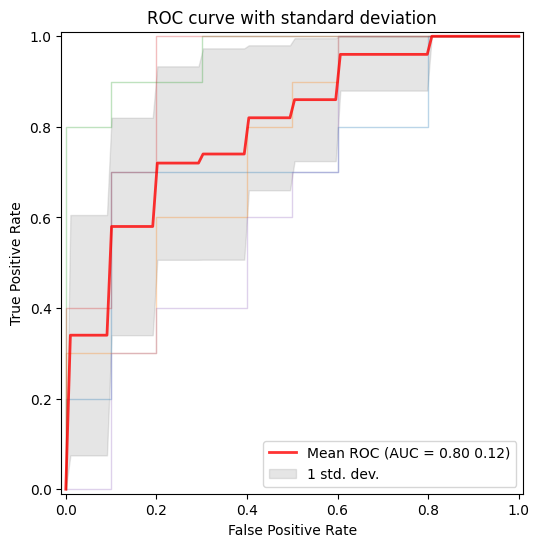

In [ ]:
# For this example the iris dataset is used, but in order to apply it succesfully for binary classification,
# the dataset is reduced to two classes and the features are increased by adding noise.

# Step 1: Data loading and preprocessing
iris = load_iris()
target_names = iris.target_names
X, y = iris.data, iris.target
X, y = X[y != 2], y[y != 2]
n_samples, n_features = X.shape

# Step 2: Adding noise to the data
random_state = np.random.RandomState(0)
X = np.concatenate([X, random_state.randn(n_samples, 300 * n_features)], axis=1)

# Step 3: Application of  cross-validation
cv = StratifiedKFold(n_splits=5)
splits = list(cv.split(X, y))

# Step 4: Training of a SVM algorithm
y_probs_folds = []
y_true_folds = []

classifier = svm.SVC(kernel="linear", probability=True, random_state=random_state)

# Obtaining the probabilities and true labels for each fold
for train_idx, test_idx in splits:
    # Train and predict
    classifier.fit(X[train_idx], y[train_idx])
    y_probs_folds.append(classifier.predict_proba(X[test_idx])[:, 1])  # Probabilities for the positive class
    y_true_folds.append(y[test_idx])  # True labels for the fold

# Call the function to plot the ROC curve with the standard deviation
plot_roc_curve_with_std(y_probs_folds, y_true_folds, fold_legend_info = False)

### Fourier Ring Correlation

#### Radial mask

In [0]:
#| echo: false
#| output: asis
show_doc(radial_mask)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L58){target="_blank" style="float:right; font-size:smaller"}

### radial_mask

```python

def radial_mask(
    r, # Radius of the radial mask
    cx:int=128, # X coordinate mask center
    cy:int=128, # Y coordinate maske center
    sx:int=256, # Size of the x-axis
    sy:int=256, # Size of the y-axis
    delta:int=1, # Thickness adjustment for the circular mask
):


```

*Generate a radial mask.*

Returns:
   - numpy.ndarray: Radial mask.

In [0]:
#| echo: false
#| output: asis
show_doc(get_radial_masks)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L90){target="_blank" style="float:right; font-size:smaller"}

### get_radial_masks

```python

def get_radial_masks(
    width, # Width of the image
    height, # Height of the image
):


```

*Generates a set of radial masks and corresponding to spatial frequencies.*

Returns:
    tuple: A tuple containing:
        - numpy.ndarray: Array of radial masks.
        - numpy.ndarray: Array of spatial frequencies corresponding to the masks.

#### Fourier ring correlation

In [0]:
#| echo: false
#| output: asis
show_doc(get_fourier_ring_correlations)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L121){target="_blank" style="float:right; font-size:smaller"}

### get_fourier_ring_correlations

```python

def get_fourier_ring_correlations(
    image1, # First input image
    image2, # Second input image
):


```

*Compute Fourier Ring Correlation (FRC) between two images.*

Returns:
    tuple: A tuple containing:
        - torch.Tensor: Fourier Ring Correlation values.
        - torch.Tensor: Array of spatial frequencies.

In [0]:
#| echo: false
#| output: asis
show_doc(FRCMetric)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/metrics.py#L189){target="_blank" style="float:right; font-size:smaller"}

### FRCMetric

```python

def FRCMetric(
    image1, # First input image
    image2, # Second input image
):


```

*Compute the area under the Fourier Ring Correlation (FRC) curve between two images.*

Returns:
    - float: The area under the FRC curve.

---